In [ ]:
# ==========================================
#Assignment 1 (Neural Network-Based Credit Risk Prediction)
#NAME: Ashish Raj
#Roll Number: 2501940024
#Course Code & Title: Deep Learning Architectures and Techniques(ETMMDL274)
#MCA(AI&ML)
# ==========================================

In [1]:
import pandas as pd

# URL for the UCI German Credit Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Loading the dataset (it uses spaces as separators and has no header row initially)
df = pd.read_csv(url, sep=' ', header=None)

# Displaying the shape and the first 5 rows to check if it loaded successfully
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [2]:
# ==========================================
# Data Preprocessing & Feature Handling
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Map target variable to 0 and 1 for binary classification
y = y.map({1: 0, 2: 1})

# 1. Handle missing values
print("Total missing values before processing:", X.isnull().sum().sum())

# 2. Encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

# *** THE FIX: Convert all column names to strings to avoid StandardScaler error ***
X_encoded.columns = X_encoded.columns.astype(str)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 3. Normalize or standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Total missing values before processing: 0
Training data shape: (800, 48)
Testing data shape: (200, 48)


In [3]:
# ==========================================
# Multi-Layer Perceptron (MLP) Architecture
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Initialize the Sequential model
model = Sequential()

# 2. Add the First Hidden Layer
# We use 'relu' activation and specify the input shape based on our scaled features
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# 3. Add the Second Hidden Layer
model.add(Dense(32, activation='relu'))

# 4. Add the Output Layer
# Since it's binary classification (predicting credit risk), we use 1 neuron with 'sigmoid' activation
model.add(Dense(1, activation='sigmoid'))

# 5. Compile the model
# Using 'adam' optimizer and 'binary_crossentropy' loss as required
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Display the model architecture summary
model.summary()

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.6025 - loss: 0.6605 - val_accuracy: 0.7000 - val_loss: 0.5879
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7125 - loss: 0.5522 - val_accuracy: 0.7250 - val_loss: 0.5572
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7350 - loss: 0.5136 - val_accuracy: 0.7450 - val_loss: 0.5395
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7725 - loss: 0.4830 - val_accuracy: 0.7550 - val_loss: 0.5263
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7825 - loss: 0.4586 - val_accuracy: 0.7750 - val_loss: 0.5146
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7900 - loss: 0.4349 - val_accuracy: 0.7800 - val_loss: 0.5108
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8037 - loss: 0.4164 - val_accuracy: 0.7700 - val_loss: 0.5073
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8100 - loss: 0.3965 - val_accuracy: 0.7800 - v

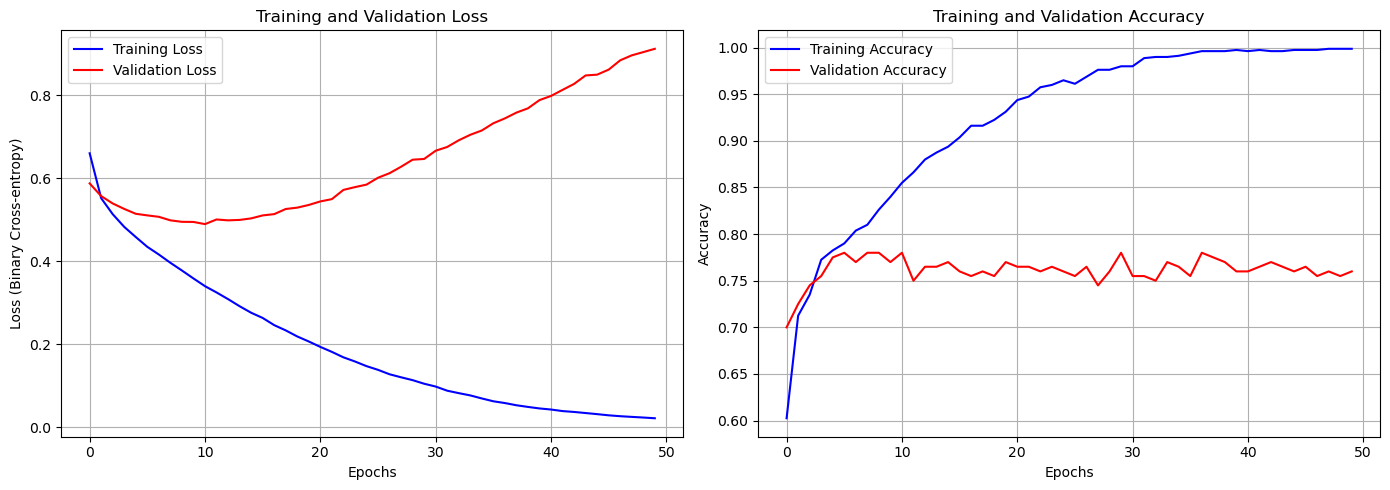

In [4]:
# ==========================================
# Model Training & Visualizing Learning Curves
# ==========================================

import matplotlib.pyplot as plt

# 1. Train the model
# We are training for 50 epochs and using our test data for validation
history = model.fit(X_train_scaled, y_train, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(X_test_scaled, y_test),
                    verbose=1)

# 2. Visualize Training and Validation Curves
plt.figure(figsize=(14, 5))

# Plot for Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross-entropy)')
plt.legend()
plt.grid(True)

# Plot for Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Display the plots
plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step 
--- Model Evaluation Metrics ---
Accuracy:  0.7600
Precision: 0.5902
Recall:    0.6102
F1-score:  0.6000
--------------------------------


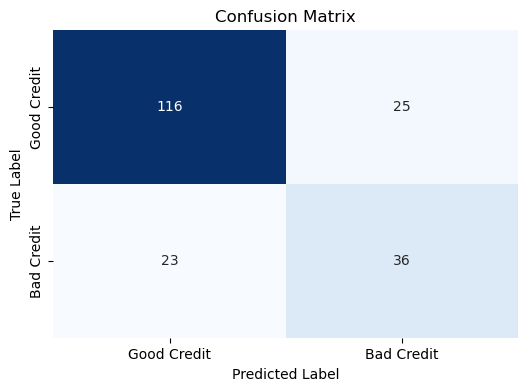

In [5]:
# ==========================================
# Performance Evaluation & Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import numpy as np

# 1. Get model predictions on the test set
# The model outputs probabilities between 0 and 1 because of the Sigmoid activation
y_pred_prob = model.predict(X_test_scaled)

# 2. Convert probabilities to binary classes (0 or 1) using a 0.5 threshold
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Calculate all required metrics
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 4. Print the metrics
print("--- Model Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("--------------------------------")

# 5. Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Good Credit', 'Bad Credit'], 
            yticklabels=['Good Credit', 'Bad Credit'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()